# LDLR Parameter Fitting with PyPESTO

This notebook demonstrates parameter fitting for the LDLR model using pypesto.
We fit BASE model parameters to match BOTH target functional score (uptake ratio) and abundance score (surface ratio) simultaneously.

In [12]:
!pip install pypesto

## 1. Imports and Setup

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypesto
import pypesto.optimize as optimize
import pypesto.visualize as visualize
from pathlib import Path
import sys

# Import our custom model
from models.ldlr_pypesto_model2 import (
    LDLRModelForFitting,
    create_objective_function,
    create_objective_function_log_scale,
    LDLR_INIT_BASE,
    K_ENDO_BASE,
    K_OFF_ENDO_BASE,
    K_RECYCLE_LDLR_BASE,
    K_LYSO_LDL_BASE,
    K_DEGRADE_LDL_BASE,
)

# Set up plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 2. Define Variant and Target

In [14]:
# Variant configuration
VARIANT_NAME = "p.Leu8Gln"
CLUSTER = 2                     # Cluster assignment

# Target scores to fit (these are OUTPUTS from the model that we want to match)
TARGET_FUNCTIONAL_SCORE = 0.65  # Target uptake ratio relative to WT
TARGET_ABUNDANCE_SCORE = 0.80   # Target surface ratio relative to WT

# Weighting for the two objectives (adjust these to prioritize one score over the other)
WEIGHT_FUNCTIONAL = 1.0  # Weight for functional score in objective
WEIGHT_ABUNDANCE = 1.0   # Weight for abundance score in objective

# Working directory
WORK_DIR = Path("results/data/pypesto_fitting")
WORK_DIR.mkdir(parents=True, exist_ok=True)

print(f"Variant: {VARIANT_NAME}")
print(f"Cluster: {CLUSTER}")
print(f"Target functional score (uptake ratio): {TARGET_FUNCTIONAL_SCORE}")
print(f"Target abundance score (surface ratio): {TARGET_ABUNDANCE_SCORE}")
print(f"Objective weights: F={WEIGHT_FUNCTIONAL}, A={WEIGHT_ABUNDANCE}")

Variant: p.Leu8Gln
Cluster: 2
Target functional score (uptake ratio): 0.65
Target abundance score (surface ratio): 0.8
Objective weights: F=1.0, A=1.0


## 3. Define Parameter Bounds

We'll define bounds for each parameter that will be optimized.

**Strategy for better convergence:**
- Start with fewer parameters (4-5 key ones)
- Fix parameters that don't strongly affect your target scores
- Based on the model biology:
  - `LDLR_init_base` affects abundance (surface ratio)
  - `k_recycle_ldlr_base` affects abundance (receptor recycling)
  - `k_endo_base` affects functional score (uptake)
  - `k_off_surf` affects both (binding affinity)

**Current parameter set (7 parameters):**
1. LDLR_init_base - Initial LDLR receptor count
2. k_endo_base - Endocytosis rate
3. k_off_endo_base - Unbinding rate in endosome
4. k_recycle_ldlr_base - LDLR recycling rate
5. k_lyso_ldl_base - LDL lysosomal routing rate
6. k_degrade_ldl_base - LDL degradation rate
7. k_off_surf - Surface unbinding rate

💡 **Tip**: If convergence is poor, try reducing to 4 parameters:
   `LDLR_init_base`, `k_endo_base`, `k_recycle_ldlr_base`, `k_off_surf`

In [15]:
# Parameter names
param_names = [
    'LDLR_init_base',
    'k_endo_base',
    'k_off_endo_base',
    'k_recycle_ldlr_base',
    'k_lyso_ldl_base',
    'k_degrade_ldl_base',
    'k_off_surf',
]

# Default values (from the model)
param_defaults = np.array([
    LDLR_INIT_BASE,       # 1000
    K_ENDO_BASE,          # 2.0
    K_OFF_ENDO_BASE,      # 50.0
    K_RECYCLE_LDLR_BASE,  # 3.0
    K_LYSO_LDL_BASE,      # 3.0
    K_DEGRADE_LDL_BASE,   # 5.0
    1.0,                  # k_off_surf
])

# Define lower bounds (0.1x default)
lb = param_defaults * 0.1

# Define upper bounds (10x default)
ub = param_defaults * 10.0

# Log-scale bounds for optimization (better for parameters spanning orders of magnitude)
lb_log = np.log10(lb)
ub_log = np.log10(ub)
param_defaults_log = np.log10(param_defaults)

# Create parameter DataFrame for display
param_df = pd.DataFrame({
    'Parameter': param_names,
    'Default': param_defaults,
    'Lower Bound': lb,
    'Upper Bound': ub,
    'Log10(Default)': param_defaults_log,
    'Log10(LB)': lb_log,
    'Log10(UB)': ub_log,
})

print("Parameter bounds (linear and log scale):")
print(param_df.to_string(index=False))
print("\n✓ Using LOG-SCALE optimization for better handling of parameters spanning 1000x magnitude")

Parameter bounds (linear and log scale):
          Parameter  Default  Lower Bound  Upper Bound  Log10(Default)  Log10(LB)  Log10(UB)
     LDLR_init_base   1000.0        100.0      10000.0        3.000000   2.000000   4.000000
        k_endo_base      2.0          0.2         20.0        0.301030  -0.698970   1.301030
    k_off_endo_base     50.0          5.0        500.0        1.698970   0.698970   2.698970
k_recycle_ldlr_base      3.0          0.3         30.0        0.477121  -0.522879   1.477121
    k_lyso_ldl_base      3.0          0.3         30.0        0.477121  -0.522879   1.477121
 k_degrade_ldl_base      5.0          0.5         50.0        0.698970  -0.301030   1.698970
         k_off_surf      1.0          0.1         10.0        0.000000  -1.000000   1.000000

✓ Using LOG-SCALE optimization for better handling of parameters spanning 1000x magnitude


## 4. Create Objective Function

In [16]:
# Create the LOG-SCALE objective function
# This optimizes in log10 space for better handling of parameters spanning multiple orders of magnitude
obj_func_log, model = create_objective_function_log_scale(
    variant_name=VARIANT_NAME,
    target_functional_score=TARGET_FUNCTIONAL_SCORE,
    target_abundance_score=TARGET_ABUNDANCE_SCORE,
    cluster=CLUSTER,
    work_dir=WORK_DIR,
    weight_functional=WEIGHT_FUNCTIONAL,
    weight_abundance=WEIGHT_ABUNDANCE,
)

# Also create linear-scale objective for comparison/testing
obj_func_linear, _ = create_objective_function(
    variant_name=VARIANT_NAME,
    target_functional_score=TARGET_FUNCTIONAL_SCORE,
    target_abundance_score=TARGET_ABUNDANCE_SCORE,
    cluster=CLUSTER,
    work_dir=WORK_DIR,
    weight_functional=WEIGHT_FUNCTIONAL,
    weight_abundance=WEIGHT_ABUNDANCE,
)

print("✓ Log-scale objective function created successfully!")
print("✓ Linear-scale objective function created for comparison")
print(f"\nFitting {len(param_names)} parameters to match both functional and abundance scores")
print("Optimizer will work in LOG10 space for better convergence")

✓ Log-scale objective function created successfully!
✓ Linear-scale objective function created for comparison

Fitting 7 parameters to match both functional and abundance scores
Optimizer will work in LOG10 space for better convergence


## 5. Test Objective Function and Check Scaling

Let's test the objective function with default parameters and check if parameter scaling might help convergence.

In [17]:
# Test with default parameters (in LOG SPACE for log-scale objective)
print("Testing LOG-SCALE objective function with default parameters...")
initial_error = obj_func_log(param_defaults_log)
print(f"Initial total error (weighted sum of squared errors): {initial_error:.6f}")
print(f"Initial RMSE: {np.sqrt(initial_error):.6f}")

# Get the metrics from the last simulation
if model.last_simulation_data is not None:
    # Simulate again to get metrics
    params_dict = dict(zip(param_names, param_defaults))
    metrics = model.simulate(params_dict)
    
    print("\nInitial simulation metrics:")
    print(f"  Predicted functional score (uptake ratio): {metrics['uptake_ratio']:.4f}")
    print(f"  Target functional score: {TARGET_FUNCTIONAL_SCORE:.4f}")
    print(f"  Functional error: {(metrics['uptake_ratio'] - TARGET_FUNCTIONAL_SCORE)**2:.6f}")
    print()
    print(f"  Predicted abundance score (surface ratio): {metrics['surface_ratio']:.4f}")
    print(f"  Target abundance score: {TARGET_ABUNDANCE_SCORE:.4f}")
    print(f"  Abundance error: {(metrics['surface_ratio'] - TARGET_ABUNDANCE_SCORE)**2:.6f}")
    print()
    print(f"  Final uptake: {metrics['final_uptake']:.2f}")
    print(f"  Final surface: {metrics['final_surface']:.2f}")

# Check parameter scale differences
print("\n" + "="*60)
print("Parameter scale analysis:")
print("="*60)
print("LOG-SCALE optimization equalizes parameter magnitudes")
print(f"Linear space: parameters span {param_defaults.max() / param_defaults.min():.1f}x")
print(f"Log space: parameters span {10**(param_defaults_log.max() - param_defaults_log.min()):.1f}x (in log units: {param_defaults_log.max() - param_defaults_log.min():.2f})")
print("\nParameter values in both scales:")
for i, name in enumerate(param_names):
    print(f"  {name:20s}: linear={param_defaults[i]:>10.2f}, log10={param_defaults_log[i]:>6.3f}")
print("\n✓ Log-scale bounds span uniformly, improving optimizer performance")

Testing LOG-SCALE objective function with default parameters...
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
Initial total error (weighted sum of squared errors): 0.162790
Initial RMSE: 0.403473
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp

Initial simulation metrics:
  Predicted functional score (uptake ratio): 1.0003
  Target functional score: 0.6500
  Functional error: 0.122743

  Predicted abundance score (surface ratio): 1.0001
  Target abundance score: 0.8000
  Abundance error: 0.040047

  Final uptake: 622.12
  Final surface: 587.84

Parameter scale analysis:
LOG-SCALE optimization equalizes parameter magnitudes
Linear space: parameters span 1000.0x
Log space: parameters span 1000.0x (in log units: 3.00)

Parameter values in both

## 5a. Explore Parameter Space with Latin Hypercube Sampling

Before optimization, let's explore the parameter space to understand:
- How parameters affect the two scores
- Whether the target scores are achievable
- If there are trade-offs between functional and abundance scores

In [20]:
from scipy.stats import qmc

# Number of LHS samples
n_samples = 1000
print(f"Generating {n_samples} Latin Hypercube samples...")
print("Sampling in LOG SPACE for uniform coverage...\n")

# Generate LHS samples in [0, 1]^d
sampler = qmc.LatinHypercube(d=len(param_names), seed=42)
samples_unit = sampler.random(n=n_samples)

# Sample in LOG SPACE for better coverage across orders of magnitude
# Scale samples to log-space bounds
samples_log = lb_log + samples_unit * (ub_log - lb_log)

# Convert back to linear space for simulation
samples = 10 ** samples_log

# Run simulations for all samples
functional_scores = []
abundance_scores = []
objective_values = []

print("Running simulations...")
for i, params in enumerate(samples):
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{n_samples} samples completed...")
    
    try:
        # Run simulation
        params_dict = dict(zip(param_names, params))
        metrics = model.simulate(params_dict)
        
        # Store scores
        functional_scores.append(metrics['uptake_ratio'])
        abundance_scores.append(metrics['surface_ratio'])
        
        # Calculate objective value using LOG-SCALE objective
        obj_val = obj_func_log(samples_log[i])
        objective_values.append(obj_val)
        
    except Exception as e:
        # If simulation fails, record as NaN
        functional_scores.append(np.nan)
        abundance_scores.append(np.nan)
        objective_values.append(np.nan)

# Convert to arrays
functional_scores = np.array(functional_scores)
abundance_scores = np.array(abundance_scores)
objective_values = np.array(objective_values)

# Remove any failed simulations
valid_mask = ~np.isnan(functional_scores) & ~np.isnan(abundance_scores)
functional_scores_valid = functional_scores[valid_mask]
abundance_scores_valid = abundance_scores[valid_mask]
objective_values_valid = objective_values[valid_mask]
samples_valid = samples[valid_mask]
samples_log_valid = samples_log[valid_mask]

print(f"\nCompleted: {np.sum(valid_mask)}/{n_samples} successful simulations")
print(f"Functional score range: [{functional_scores_valid.min():.3f}, {functional_scores_valid.max():.3f}]")
print(f"Abundance score range: [{abundance_scores_valid.min():.3f}, {abundance_scores_valid.max():.3f}]")

Generating 1000 Latin Hypercube samples...
Sampling in LOG SPACE for uniform coverage...

Running simulations...
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: re

## 5b. Visualize LHS Results

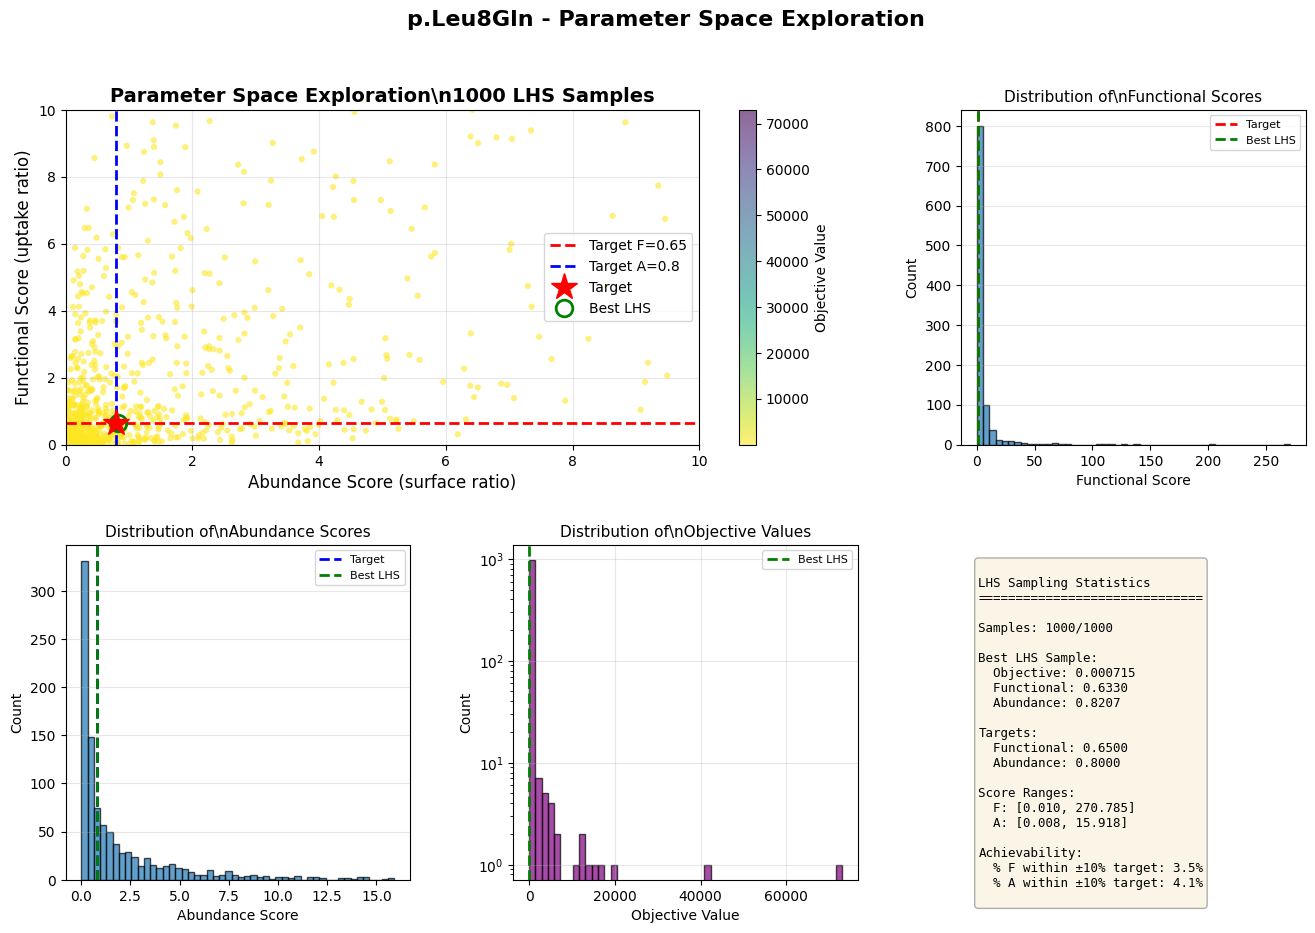

\n============================================================
Best LHS Sample Parameters:
  LDLR_init_base      :   3102.044  (default:  1000.00, ratio:  3.102)
  k_endo_base         :      5.710  (default:     2.00, ratio:  2.855)
  k_off_endo_base     :     26.465  (default:    50.00, ratio:  0.529)
  k_recycle_ldlr_base :      1.076  (default:     3.00, ratio:  0.359)
  k_lyso_ldl_base     :      8.361  (default:     3.00, ratio:  2.787)
  k_degrade_ldl_base  :     38.947  (default:     5.00, ratio:  7.789)
  k_off_surf          :      0.559  (default:     1.00, ratio:  0.559)


In [21]:
# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Main scatter plot: Functional vs Abundance scores
ax1 = fig.add_subplot(gs[0, :2])
scatter = ax1.scatter(
    abundance_scores_valid, 
    functional_scores_valid,
    c=objective_values_valid,
    cmap='viridis_r',  # Reverse so darker = better (lower objective)
    alpha=0.6,
    s=20,
    edgecolors='none'
)
ax1.axhline(TARGET_FUNCTIONAL_SCORE, color='red', linestyle='--', linewidth=2, label=f'Target F={TARGET_FUNCTIONAL_SCORE}')
ax1.axvline(TARGET_ABUNDANCE_SCORE, color='blue', linestyle='--', linewidth=2, label=f'Target A={TARGET_ABUNDANCE_SCORE}')
ax1.plot(TARGET_ABUNDANCE_SCORE, TARGET_FUNCTIONAL_SCORE, 'r*', markersize=20, label='Target', zorder=10)

# Mark best LHS sample
best_lhs_idx = np.argmin(objective_values_valid)
ax1.plot(abundance_scores_valid[best_lhs_idx], functional_scores_valid[best_lhs_idx], 
         'go', markersize=12, markeredgewidth=2, markerfacecolor='none', label='Best LHS', zorder=9)

ax1.set_xlabel('Abundance Score (surface ratio)', fontsize=12)
ax1.set_ylabel('Functional Score (uptake ratio)', fontsize=12)
ax1.set_title(f'Parameter Space Exploration\\n{n_samples} LHS Samples', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)  

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Objective Value', fontsize=10)

# 2. Histogram of functional scores
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(functional_scores_valid, bins=50, alpha=0.7, edgecolor='black')
ax2.axvline(TARGET_FUNCTIONAL_SCORE, color='red', linestyle='--', linewidth=2, label='Target')
ax2.axvline(functional_scores_valid[best_lhs_idx], color='green', linestyle='--', linewidth=2, label='Best LHS')
ax2.set_xlabel('Functional Score', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)
ax2.set_title('Distribution of\\nFunctional Scores', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

# 3. Histogram of abundance scores
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(abundance_scores_valid, bins=50, alpha=0.7, edgecolor='black')
ax3.axvline(TARGET_ABUNDANCE_SCORE, color='blue', linestyle='--', linewidth=2, label='Target')
ax3.axvline(abundance_scores_valid[best_lhs_idx], color='green', linestyle='--', linewidth=2, label='Best LHS')
ax3.set_xlabel('Abundance Score', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('Distribution of\\nAbundance Scores', fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3, axis='y')

# 4. Histogram of objective values
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(objective_values_valid, bins=50, alpha=0.7, edgecolor='black', color='purple')
ax4.axvline(objective_values_valid[best_lhs_idx], color='green', linestyle='--', linewidth=2, label='Best LHS')
ax4.set_xlabel('Objective Value', fontsize=10)
ax4.set_ylabel('Count', fontsize=10)
ax4.set_title('Distribution of\\nObjective Values', fontsize=11)
ax4.set_yscale('log')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# 5. Statistics box
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

stats_text = f"""
LHS Sampling Statistics
{'='*30}

Samples: {np.sum(valid_mask)}/{n_samples}

Best LHS Sample:
  Objective: {objective_values_valid[best_lhs_idx]:.6f}
  Functional: {functional_scores_valid[best_lhs_idx]:.4f}
  Abundance: {abundance_scores_valid[best_lhs_idx]:.4f}

Targets:
  Functional: {TARGET_FUNCTIONAL_SCORE:.4f}
  Abundance: {TARGET_ABUNDANCE_SCORE:.4f}

Score Ranges:
  F: [{functional_scores_valid.min():.3f}, {functional_scores_valid.max():.3f}]
  A: [{abundance_scores_valid.min():.3f}, {abundance_scores_valid.max():.3f}]

Achievability:
  % F within ±10% target: {100*np.sum(np.abs(functional_scores_valid - TARGET_FUNCTIONAL_SCORE) < 0.1*TARGET_FUNCTIONAL_SCORE)/len(functional_scores_valid):.1f}%
  % A within ±10% target: {100*np.sum(np.abs(abundance_scores_valid - TARGET_ABUNDANCE_SCORE) < 0.1*TARGET_ABUNDANCE_SCORE)/len(abundance_scores_valid):.1f}%
"""

ax5.text(0.05, 0.95, stats_text, transform=ax5.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle(f'{VARIANT_NAME} - Parameter Space Exploration', fontsize=16, fontweight='bold', y=0.98)
plt.show()

# Print best LHS parameters
print("\\n" + "="*60)
print("Best LHS Sample Parameters:")
print("="*60)
best_params_lhs = samples_valid[best_lhs_idx]
for name, val, default in zip(param_names, best_params_lhs, param_defaults):
    print(f"  {name:20s}: {val:>10.3f}  (default: {default:>8.2f}, ratio: {val/default:>6.3f})")

## 6. Set Up PyPESTO Problem

In [22]:
# Create pypesto objective using LOG-SCALE function
pypesto_objective = pypesto.Objective(fun=obj_func_log)

# Alternative: Add finite difference gradients for optimizers that need them
# Uncomment these lines to enable gradients:
# from pypesto.objective.finite_difference import FD
# pypesto_objective = pypesto.Objective(
#     fun=obj_func_log,
#     grad=FD(obj_func_log, method='central'),  # Central finite differences
# )

# Create pypesto problem with LOG-SCALE BOUNDS
problem = pypesto.Problem(
    objective=pypesto_objective,
    lb=lb_log,  # Lower bounds in log10 space
    ub=ub_log,  # Upper bounds in log10 space
    x_names=param_names,  # Names remain the same (optimizer knows they're log-scaled)
)

print("PyPESTO problem created successfully!")
print(f"Number of parameters: {problem.dim}")
print(f"Parameter names: {problem.x_names}")
print(f"Gradients enabled: {pypesto_objective.has_grad}")
print("\n✓ Optimization will run in LOG10 space")
print(f"  Log bounds: [{lb_log.min():.2f}, {ub_log.max():.2f}]")
print(f"  Linear bounds: [{lb.min():.1f}, {ub.max():.1f}]")

PyPESTO problem created successfully!
Number of parameters: 7
Parameter names: ['LDLR_init_base', 'k_endo_base', 'k_off_endo_base', 'k_recycle_ldlr_base', 'k_lyso_ldl_base', 'k_degrade_ldl_base', 'k_off_surf']
Gradients enabled: False

✓ Optimization will run in LOG10 space
  Log bounds: [-1.00, 4.00]
  Linear bounds: [0.1, 10000.0]


## 7. Run Optimization

We'll use multiple optimizers and starting points to find the best fit.

In [23]:
# Choose optimizer
# For complex problems without analytical gradients, use gradient-free or finite-difference methods

# Option 1: Scipy with trust-constr (handles constraints well, uses finite differences)
optimizer = optimize.ScipyOptimizer(
    method='L-BFGS-B', #trust-constr',  # Good for constrained optimization
    options={
        'maxiter': 5000,
        'verbose': 1,        # Show progress
    }
)
optimizer_name = "Scipy trust-constr"

# Option 2: If you want to try Fides with finite difference gradients:
# from pypesto.objective.finite_difference import FD
# pypesto_objective_with_grad = pypesto.Objective(
#     fun=obj_func,
#     grad=FD(obj_func, method='central')  # Finite difference gradients
# )
# optimizer = optimize.FidesOptimizer(verbose=1)
# optimizer_name = "Fides (with FD gradients)"

# Option 3: Particle Swarm (gradient-free, global optimizer)
# Uncomment to try:
# try:
#     from pypesto.optimize import PyswarmOptimizer
#     optimizer = PyswarmOptimizer()
#     optimizer_name = "Particle Swarm (gradient-free)"
# except ImportError:
#     pass  # Use default optimizer above

# Number of starts (multi-start optimization)
n_starts = 10

# Enable history recording for visualization
history_options = pypesto.HistoryOptions(trace_record=True)

print(f"Running optimization with {n_starts} starts...")
print(f"Optimizer: {optimizer_name}")
print("This may take several minutes...\n")

# Run optimization
result = optimize.minimize(
    problem=problem,
    optimizer=optimizer,
    n_starts=n_starts,
    history_options=history_options,
)

print("\nOptimization complete!")
print(f"Best objective value: {result.optimize_result.fval[0]:.8f}")

Running optimization with 10 starts...
Optimizer: Scipy trust-constr
This may take several minutes...



  0%|                                                                                            | 0/10 [00:00<?, ?it/s]

[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl


/home/tianyi/miniforge3/lib/python3.12/site-packages/pypesto/optimize/optimizer.py:621: OptimizeWarning: Unknown solver options: verbose
  res = scipy.optimize.minimize(


[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gl

...

[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl


/home/tianyi/miniforge3/lib/python3.12/site-packages/pypesto/optimize/optimizer.py:621: OptimizeWarning: Unknown solver options: verbose
  res = scipy.optimize.minimize(


[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gl

100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:46<00:00,  4.65s/it]

[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] BNGL written to: results/data/pypesto_fitting/p.Leu8Gln/p.Leu8Gln/p.Leu8Gln_temp.bngl
[DEBUG] Using GDAT key: p.Leu8Gln_temp
[DEBUG] Using GDAT key: p.Leu8Gln_temp

Optimization complete!
Best objective value: 0.05058850


## 8. Analyze Results

In [24]:
# Get best parameters (in LOG SPACE from optimizer)
best_params_log = result.optimize_result.x[0]
best_fval = result.optimize_result.fval[0]

# Transform back to LINEAR SPACE for interpretation
best_params = 10 ** best_params_log

print("Best fit parameters:")
print("=" * 60)
results_df = pd.DataFrame({
    'Parameter': param_names,
    'Default': param_defaults,
    'Optimized': best_params,
    'Ratio (Opt/Default)': best_params / param_defaults,
    'Log10(Default)': param_defaults_log,
    'Log10(Optimized)': best_params_log,
    'Log10 Change': best_params_log - param_defaults_log,
})
print(results_df.to_string(index=False))
print("\n" + "=" * 60)
print(f"Best objective value (total error): {best_fval:.8f}")
print(f"Best RMSE: {np.sqrt(best_fval):.8f}")

# Run simulation with best parameters
best_params_dict = dict(zip(param_names, best_params))
best_metrics = model.simulate(best_params_dict)

print("\nBest fit metrics:")
print("=" * 60)
print("FUNCTIONAL SCORE (uptake ratio):")
print(f"  Predicted: {best_metrics['uptake_ratio']:.6f}")
print(f"  Target:    {TARGET_FUNCTIONAL_SCORE:.6f}")
print(f"  Error:     {abs(best_metrics['uptake_ratio'] - TARGET_FUNCTIONAL_SCORE):.6f}")
print(f"  % Error:   {100*abs(best_metrics['uptake_ratio'] - TARGET_FUNCTIONAL_SCORE)/TARGET_FUNCTIONAL_SCORE:.2f}%")
print()
print("ABUNDANCE SCORE (surface ratio):")
print(f"  Predicted: {best_metrics['surface_ratio']:.6f}")
print(f"  Target:    {TARGET_ABUNDANCE_SCORE:.6f}")
print(f"  Error:     {abs(best_metrics['surface_ratio'] - TARGET_ABUNDANCE_SCORE):.6f}")
print(f"  % Error:   {100*abs(best_metrics['surface_ratio'] - TARGET_ABUNDANCE_SCORE)/TARGET_ABUNDANCE_SCORE:.2f}%")

Best fit parameters:
          Parameter  Default  Optimized  Ratio (Opt/Default)  Log10(Default)  Log10(Optimized)  Log10 Change
     LDLR_init_base   1000.0 387.554738             0.387555        3.000000          2.588333     -0.411667
        k_endo_base      2.0   3.970444             1.985222        0.301030          0.598839      0.297809
    k_off_endo_base     50.0 500.000000            10.000000        1.698970          2.698970      1.000000
k_recycle_ldlr_base      3.0  30.000000            10.000000        0.477121          1.477121      1.000000
    k_lyso_ldl_base      3.0   7.603502             2.534501        0.477121          0.881014      0.403892
 k_degrade_ldl_base      5.0   5.218196             1.043639        0.698970          0.717520      0.018550
         k_off_surf      1.0   0.232532             0.232532        0.000000         -0.633518     -0.633518

Best objective value (total error): 0.05058850
Best RMSE: 0.22491887
[DEBUG] BNGL written to: results/data

## 9. Visualize Optimization Results

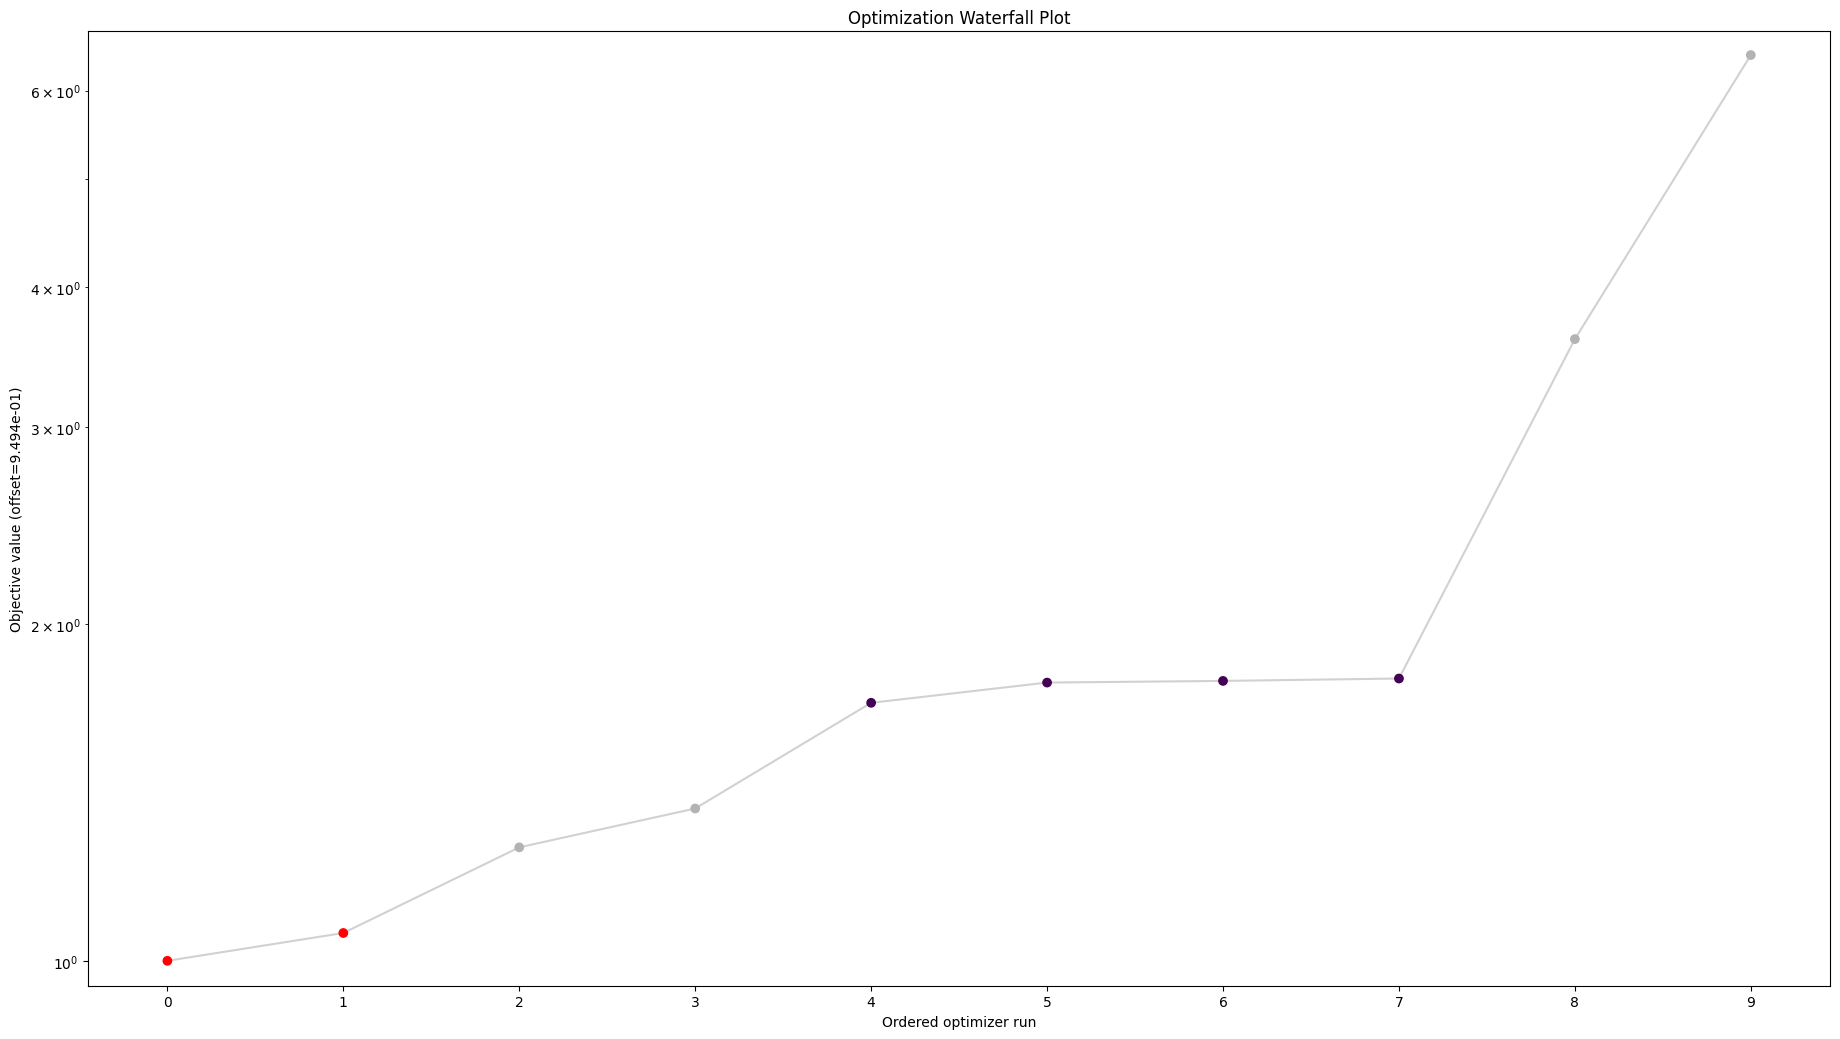

In [25]:
# Waterfall plot - shows objective values for all starts
visualize.waterfall(result)
plt.title('Optimization Waterfall Plot')
plt.tight_layout()
plt.show()

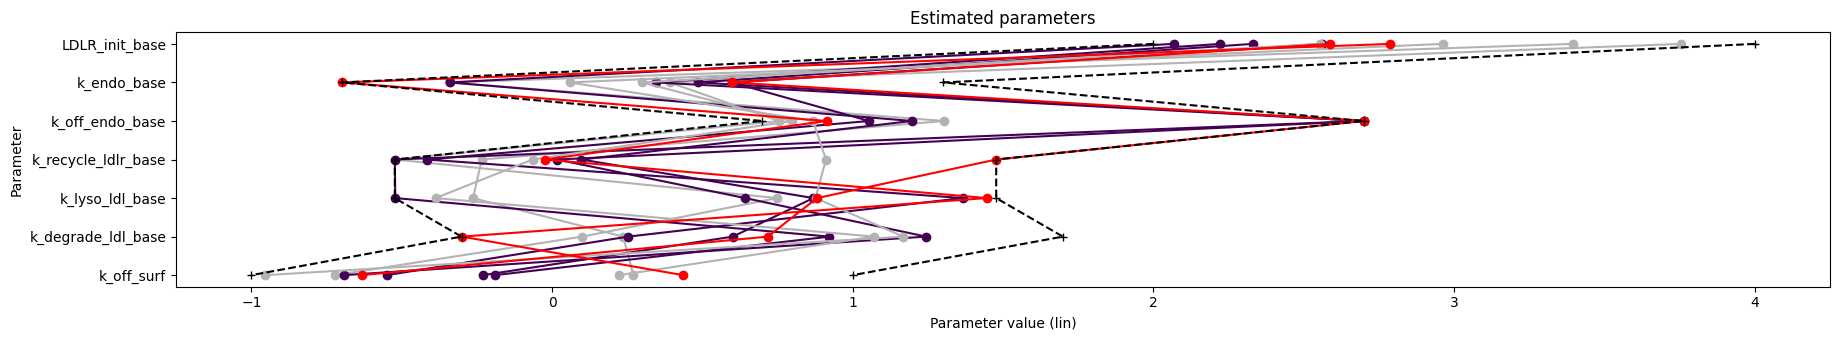

In [26]:
# Parameter plot - shows optimized parameters from all starts
visualize.parameters(result)
plt.tight_layout()
plt.show()

### 9b. Parameter Variability in Log Scale

Compare parameter variability across optimization starts in log scale, which equalizes the comparison across parameters with different magnitudes.

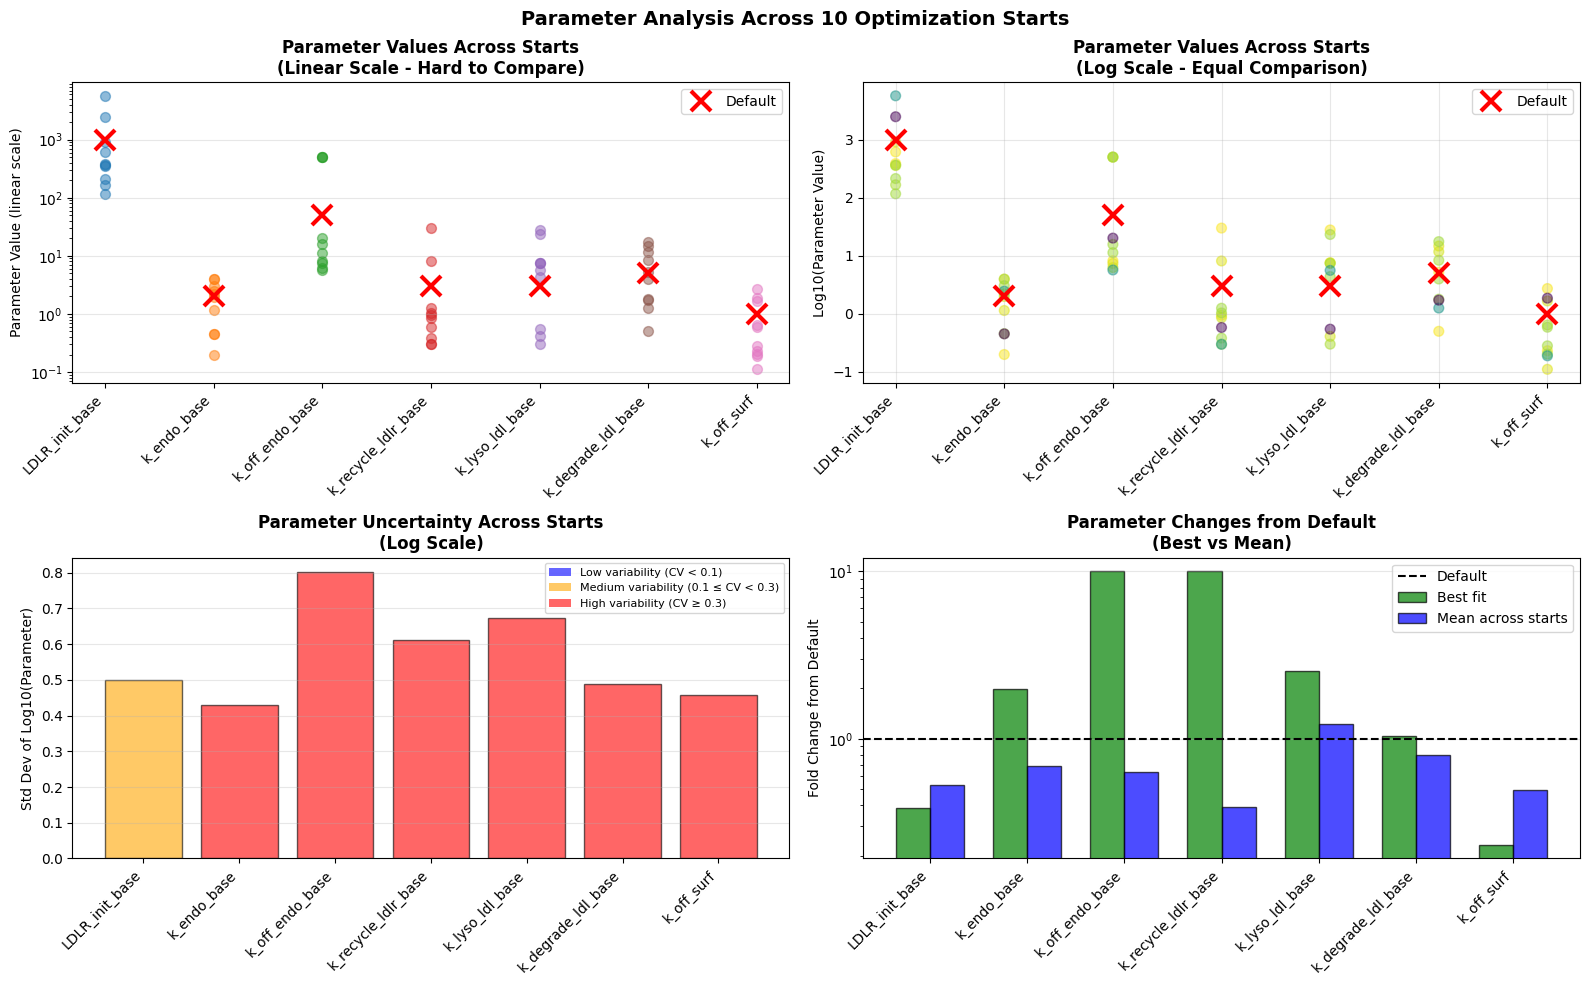

PARAMETER VARIABILITY SUMMARY (Log Scale)
Parameter            Mean (log)   Std (log)    CV (log)     Mean (linear)  
--------------------------------------------------------------------------------
LDLR_init_base             2.722       0.498       0.183         527.16
k_endo_base                0.139       0.430       3.085           1.38
k_off_endo_base            1.499       0.802       0.535          31.52
k_recycle_ldlr_base        0.072       0.612       8.518           1.18
k_lyso_ldl_base            0.566       0.672       1.188           3.68
k_degrade_ldl_base         0.601       0.489       0.813           3.99
k_off_surf                -0.304       0.457       1.503           0.50

Interpretation:
  • Low CV (<0.1): Parameter well-constrained by data
  • Medium CV (0.1-0.3): Moderate uncertainty
  • High CV (>0.3): High uncertainty, may need fixing or better constraints


In [27]:
# Extract all optimization results and transform to linear space
n_starts_completed = len(result.optimize_result.x)
all_params_log = np.array([result.optimize_result.x[i] for i in range(n_starts_completed)])
all_params_linear = 10 ** all_params_log
all_fvals = np.array([result.optimize_result.fval[i] for i in range(n_starts_completed)])

# Create comprehensive parameter comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Linear scale parameters (traditional view)
ax1 = axes[0, 0]
for i in range(len(param_names)):
    values = all_params_linear[:, i]
    ax1.scatter([i]*len(values), values, alpha=0.5, s=50)
    ax1.plot([i], param_defaults[i], 'rx', markersize=15, markeredgewidth=3, label='Default' if i==0 else '')
    
ax1.set_xticks(range(len(param_names)))
ax1.set_xticklabels(param_names, rotation=45, ha='right')
ax1.set_ylabel('Parameter Value (linear scale)')
ax1.set_title('Parameter Values Across Starts\n(Linear Scale - Hard to Compare)', fontweight='bold')
ax1.set_yscale('log')  # Use log scale to see all parameters
ax1.grid(alpha=0.3, axis='y')
ax1.legend()

# 2. Log scale parameters (equal comparison)
ax2 = axes[0, 1]
for i in range(len(param_names)):
    values = all_params_log[:, i]
    ax2.scatter([i]*len(values), values, alpha=0.5, s=50, c=all_fvals, cmap='viridis_r')
    ax2.plot([i], param_defaults_log[i], 'rx', markersize=15, markeredgewidth=3, label='Default' if i==0 else '')
    
ax2.set_xticks(range(len(param_names)))
ax2.set_xticklabels(param_names, rotation=45, ha='right')
ax2.set_ylabel('Log10(Parameter Value)')
ax2.set_title('Parameter Values Across Starts\n(Log Scale - Equal Comparison)', fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

# 3. Parameter variability (coefficient of variation in log space)
ax3 = axes[1, 0]
log_std = np.std(all_params_log, axis=0)
log_mean = np.mean(all_params_log, axis=0)
log_cv = log_std / np.abs(log_mean)  # Coefficient of variation

colors = ['blue' if cv < 0.1 else 'orange' if cv < 0.3 else 'red' for cv in log_cv]
bars = ax3.bar(range(len(param_names)), log_std, color=colors, alpha=0.6, edgecolor='black')
ax3.set_xticks(range(len(param_names)))
ax3.set_xticklabels(param_names, rotation=45, ha='right')
ax3.set_ylabel('Std Dev of Log10(Parameter)')
ax3.set_title('Parameter Uncertainty Across Starts\n(Log Scale)', fontweight='bold')
ax3.grid(alpha=0.3, axis='y')

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.6, label='Low variability (CV < 0.1)'),
    Patch(facecolor='orange', alpha=0.6, label='Medium variability (0.1 ≤ CV < 0.3)'),
    Patch(facecolor='red', alpha=0.6, label='High variability (CV ≥ 0.3)')
]
ax3.legend(handles=legend_elements, fontsize=8)

# 4. Fold-change from default (easier to interpret biologically)
ax4 = axes[1, 1]
best_fold_changes = best_params / param_defaults
mean_params_linear = 10 ** log_mean
mean_fold_changes = mean_params_linear / param_defaults

x = np.arange(len(param_names))
width = 0.35
bars1 = ax4.bar(x - width/2, best_fold_changes, width, label='Best fit', alpha=0.7, color='green', edgecolor='black')
bars2 = ax4.bar(x + width/2, mean_fold_changes, width, label='Mean across starts', alpha=0.7, color='blue', edgecolor='black')

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, label='Default')
ax4.set_xticks(x)
ax4.set_xticklabels(param_names, rotation=45, ha='right')
ax4.set_ylabel('Fold Change from Default')
ax4.set_title('Parameter Changes from Default\n(Best vs Mean)', fontweight='bold')
ax4.set_yscale('log')
ax4.grid(alpha=0.3, axis='y')
ax4.legend()

plt.suptitle(f'Parameter Analysis Across {n_starts_completed} Optimization Starts', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("="*80)
print("PARAMETER VARIABILITY SUMMARY (Log Scale)")
print("="*80)
print(f"{'Parameter':<20} {'Mean (log)':<12} {'Std (log)':<12} {'CV (log)':<12} {'Mean (linear)':<15}")
print("-"*80)
for i, name in enumerate(param_names):
    mean_lin = 10 ** log_mean[i]
    print(f"{name:<20} {log_mean[i]:>11.3f} {log_std[i]:>11.3f} {log_cv[i]:>11.3f} {mean_lin:>14.2f}")
print("="*80)
print("\nInterpretation:")
print("  • Low CV (<0.1): Parameter well-constrained by data")
print("  • Medium CV (0.1-0.3): Moderate uncertainty")
print("  • High CV (>0.3): High uncertainty, may need fixing or better constraints")

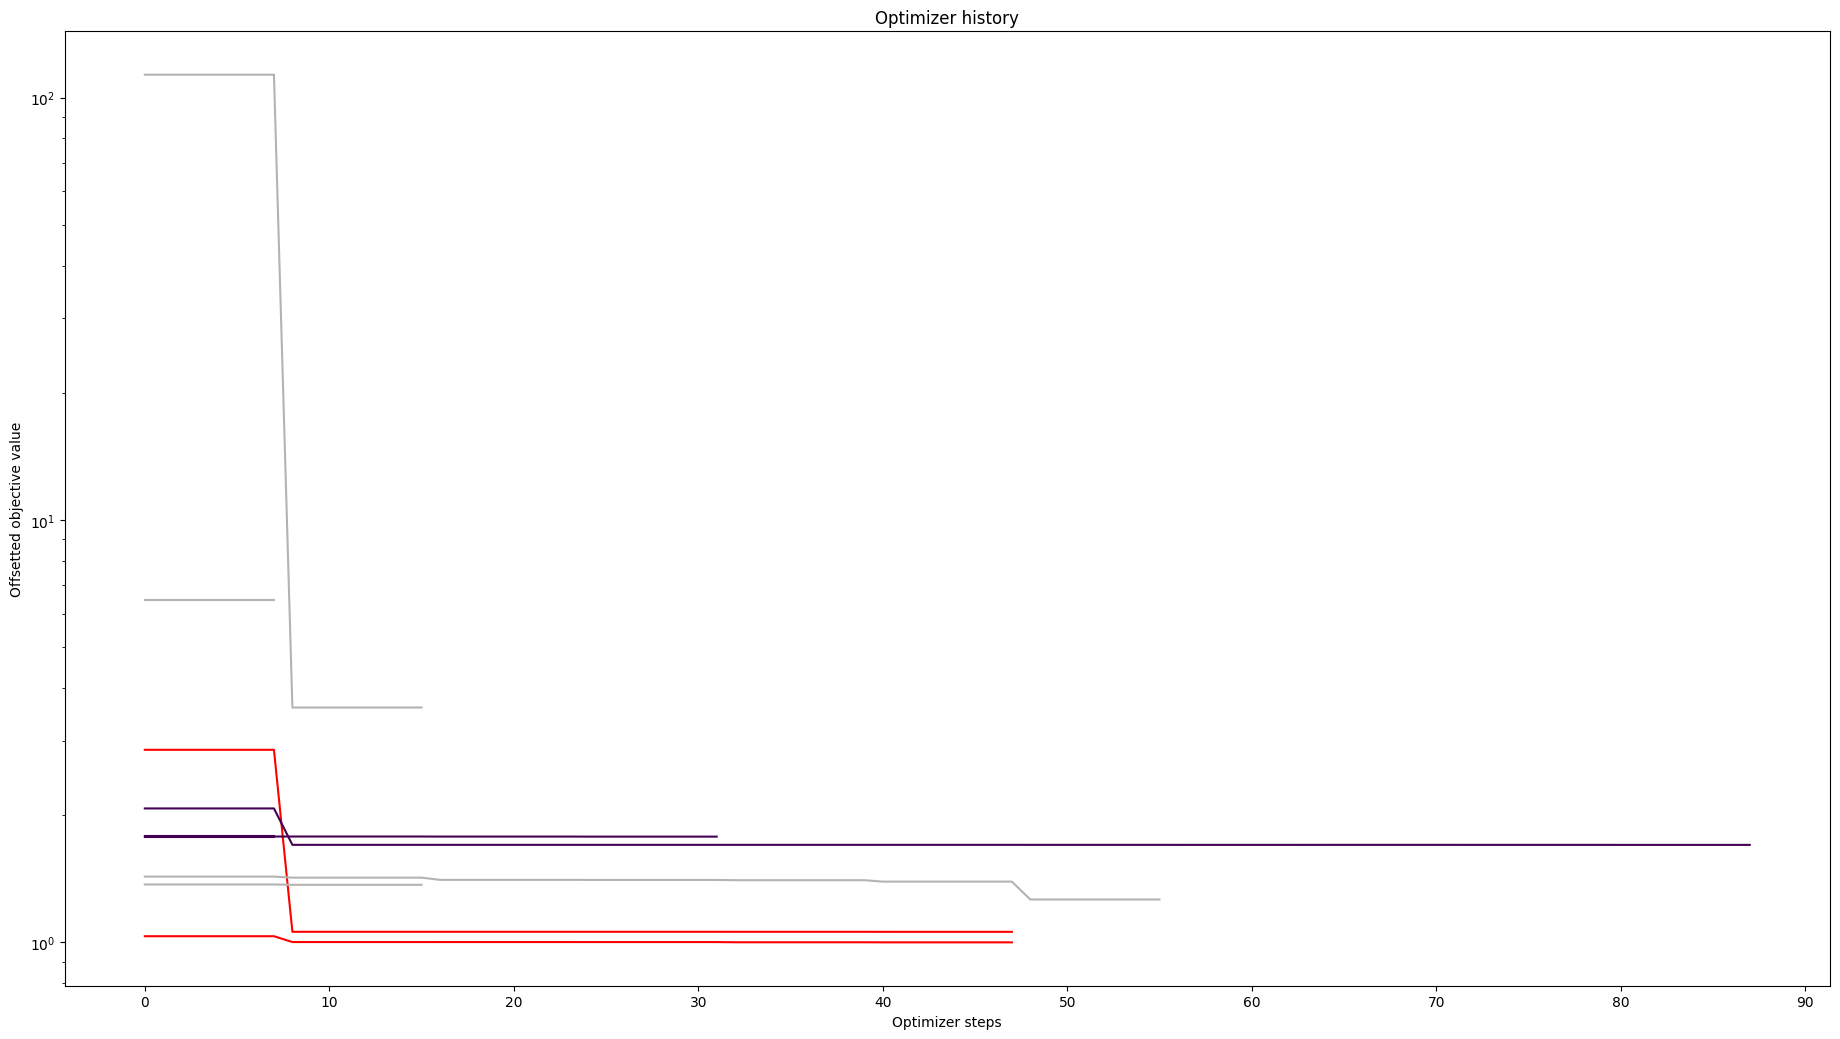

In [28]:
# Optimizer history - shows convergence
visualize.optimizer_history(result)
plt.tight_layout()
plt.show()

## 10. Simulate with Best Parameters

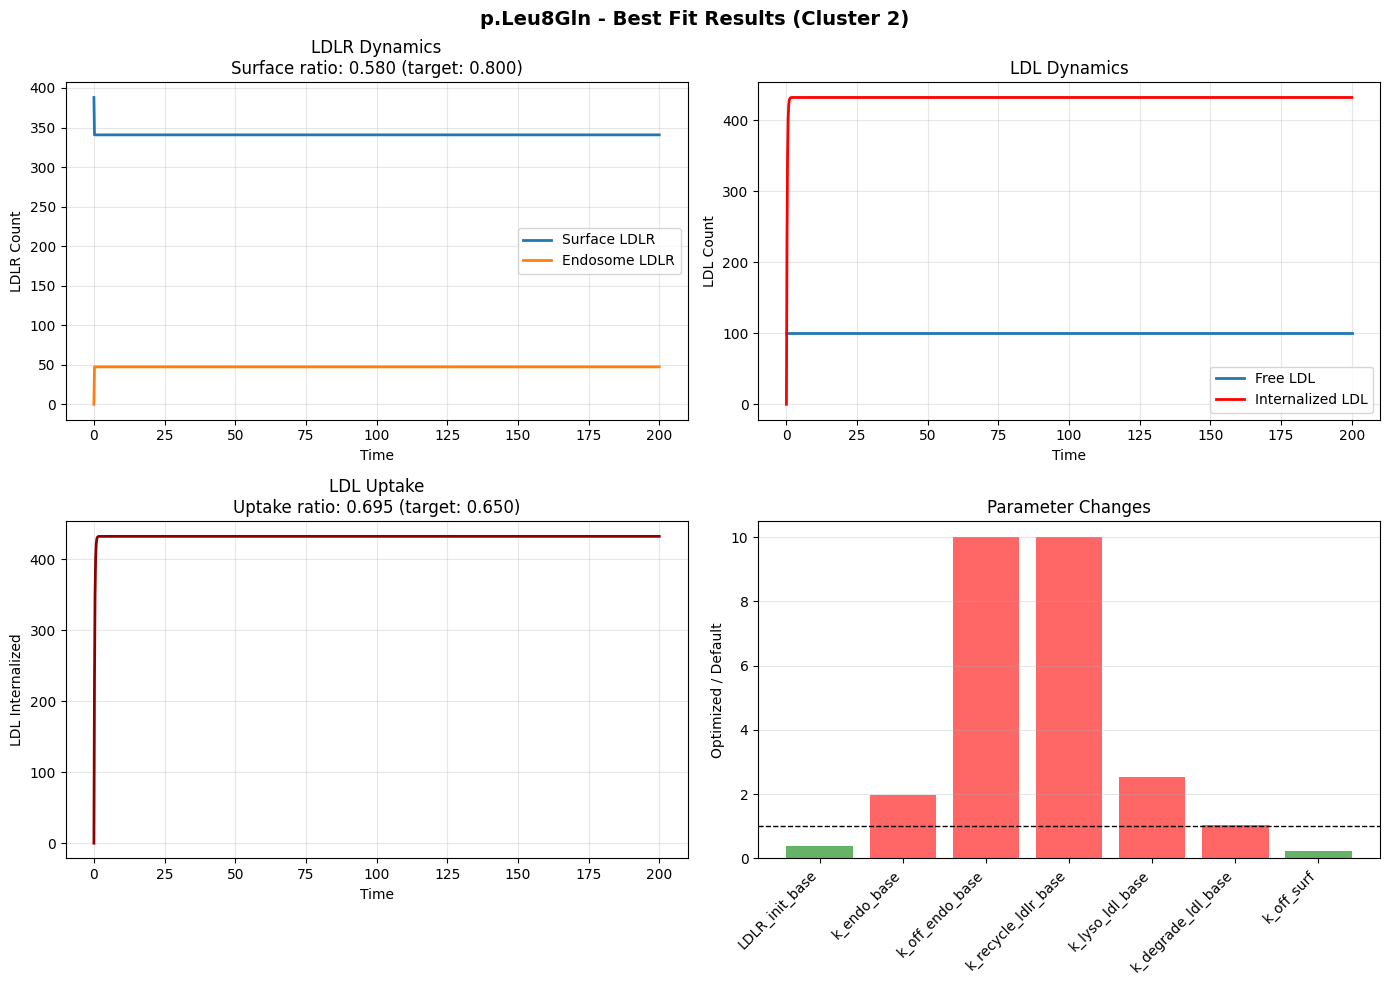

In [29]:
# Get the simulation data
sim_data = model.last_simulation_data

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LDLR dynamics
axes[0, 0].plot(sim_data['time'], sim_data['LDLR_surface'], label='Surface LDLR', linewidth=2)
axes[0, 0].plot(sim_data['time'], sim_data['LDLR_endosome'], label='Endosome LDLR', linewidth=2)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('LDLR Count')
axes[0, 0].set_title(f'LDLR Dynamics\nSurface ratio: {best_metrics["surface_ratio"]:.3f} (target: {TARGET_ABUNDANCE_SCORE:.3f})')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# LDL dynamics
axes[0, 1].plot(sim_data['time'], sim_data['LDL_free'], label='Free LDL', linewidth=2)
axes[0, 1].plot(sim_data['time'], sim_data['LDL_internalized'], 
               label='Internalized LDL', linewidth=2, color='red')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('LDL Count')
axes[0, 1].set_title('LDL Dynamics')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# LDL uptake
axes[1, 0].plot(sim_data['time'], sim_data['LDL_internalized'], 
               linewidth=2, color='darkred')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('LDL Internalized')
axes[1, 0].set_title(f'LDL Uptake\nUptake ratio: {best_metrics["uptake_ratio"]:.3f} (target: {TARGET_FUNCTIONAL_SCORE:.3f})')
axes[1, 0].grid(alpha=0.3)

# Parameter comparison
x_pos = np.arange(len(param_names))
ratios = best_params / param_defaults
colors = ['green' if r < 1 else 'red' if r > 1 else 'gray' for r in ratios]
axes[1, 1].bar(x_pos, ratios, color=colors, alpha=0.6)
axes[1, 1].axhline(y=1.0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(param_names, rotation=45, ha='right')
axes[1, 1].set_ylabel('Optimized / Default')
axes[1, 1].set_title('Parameter Changes')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.suptitle(f'{VARIANT_NAME} - Best Fit Results (Cluster {CLUSTER})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Save Results

In [30]:
# Save results to CSV
output_file = WORK_DIR / f"{VARIANT_NAME}_fitted_parameters.csv"
results_df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

# Save metrics
metrics_file = WORK_DIR / f"{VARIANT_NAME}_metrics.txt"
with open(metrics_file, 'w') as f:
    f.write(f"Variant: {VARIANT_NAME}\n")
    f.write(f"Cluster: {CLUSTER}\n")
    f.write(f"\nTarget scores:\n")
    f.write(f"  Target functional score (uptake ratio): {TARGET_FUNCTIONAL_SCORE}\n")
    f.write(f"  Target abundance score (surface ratio): {TARGET_ABUNDANCE_SCORE}\n")
    f.write(f"\nBest fit metrics:\n")
    f.write(f"  Predicted functional score: {best_metrics['uptake_ratio']:.6f}\n")
    f.write(f"  Functional error: {abs(best_metrics['uptake_ratio'] - TARGET_FUNCTIONAL_SCORE):.6f}\n")
    f.write(f"  Predicted abundance score: {best_metrics['surface_ratio']:.6f}\n")
    f.write(f"  Abundance error: {abs(best_metrics['surface_ratio'] - TARGET_ABUNDANCE_SCORE):.6f}\n")
    f.write(f"\nSimulation outputs:\n")
    f.write(f"  Final uptake: {best_metrics['final_uptake']:.2f}\n")
    f.write(f"  Final surface: {best_metrics['final_surface']:.2f}\n")
    f.write(f"\nOptimization:\n")
    f.write(f"  Total objective value: {best_fval:.8f}\n")
    f.write(f"  RMSE: {np.sqrt(best_fval):.8f}\n")
    f.write(f"  Weight functional: {WEIGHT_FUNCTIONAL}\n")
    f.write(f"  Weight abundance: {WEIGHT_ABUNDANCE}\n")
    
print(f"Metrics saved to: {metrics_file}")

Results saved to: results/data/pypesto_fitting/p.Leu8Gln_fitted_parameters.csv
Metrics saved to: results/data/pypesto_fitting/p.Leu8Gln_metrics.txt


## Next Steps

### If Convergence is Poor

**Common Issues and Solutions:**

1. **Too many parameters** (7 parameters for 2 objectives)
   - Fix some parameters at known values to reduce dimensionality
   - Example: Fix `k_lyso_ldl_base` and `k_degrade_ldl_base` at defaults
   
2. **Parameter scaling issues** (LDLR_init ~1000, other params ~1-50)
   - Use normalized/scaled parameters
   - Work in log-space for parameters with wide ranges
   
3. **Flat objective landscape**
   - Some parameters may not strongly affect both scores
   - Try sensitivity analysis to identify important parameters
   
4. **Local minima**
   - Increase `n_starts` to 20-50 for better global search
   - Try different optimizers (Fides, scipy trust-constr, ipopt)

**Quick Fixes to Try:**

```python
# Option 1: Reduce parameter count by fixing some parameters
# Modify parameter_bounds cell to only fit key parameters:
# LDLR_init_base, k_endo_base, k_recycle_ldlr_base, k_off_surf

# Option 2: Adjust weight balance if one score is much harder to fit
WEIGHT_FUNCTIONAL = 2.0  # Prioritize functional score
WEIGHT_ABUNDANCE = 1.0

# Option 3: Use tighter parameter bounds based on biology
# Instead of 0.1x-10x, use 0.5x-2x if you have prior knowledge

# Option 4: Try different optimizer
from pypesto.optimize import IpoptOptimizer
optimizer = IpoptOptimizer()
```

### Optimization Improvements
1. **Adjust parameter bounds**: If optimized parameters hit the bounds, consider widening them
2. **Try different optimizers**: PyPESTO supports many optimizers:
   - `fides`: Trust-region optimizer (often better for nonlinear problems) ⭐
   - `scipy` methods: L-BFGS-B, TNC, SLSQP, trust-constr
   - `ipopt`: Interior point optimizer (needs ipopt installed)
3. **Increase n_starts**: More starting points help find global optimum (try 20-50)
4. **Adjust weights**: Change `WEIGHT_FUNCTIONAL` and `WEIGHT_ABUNDANCE` to prioritize one score
5. **Add parameter constraints**: Use pypesto constraints for mechanistic relationships

### Analysis and Validation
6. **Profile likelihood**: Use `pypesto.profile` to assess parameter identifiability
7. **Uncertainty analysis**: Use `pypesto.sample` for Bayesian uncertainty quantification
8. **Ensemble analysis**: Examine all optimization results, not just the best
9. **Sensitivity analysis**: Test how changes in parameters affect both scores

### Batch Fitting
10. **Fit multiple variants**: Create a loop to fit parameters for all variants in your dataset
11. **Compare across clusters**: Analyze how optimal parameters differ by cluster assignment

### Model Refinement
12. **Fix certain parameters**: If some parameters are well-known, remove them from optimization
13. **Add more parameters**: Include module strengths (strength_LA3, strength_LA4, etc.) in fitting
14. **Multi-objective optimization**: Use Pareto optimization if trade-offs exist between scores